<a href="https://colab.research.google.com/github/Mizharrrrrhidi1818/DecisionTreeAlgorithm/blob/main/Lab3_TantriMizharArofahidi_ClassificationTaskAssignment_DAIB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

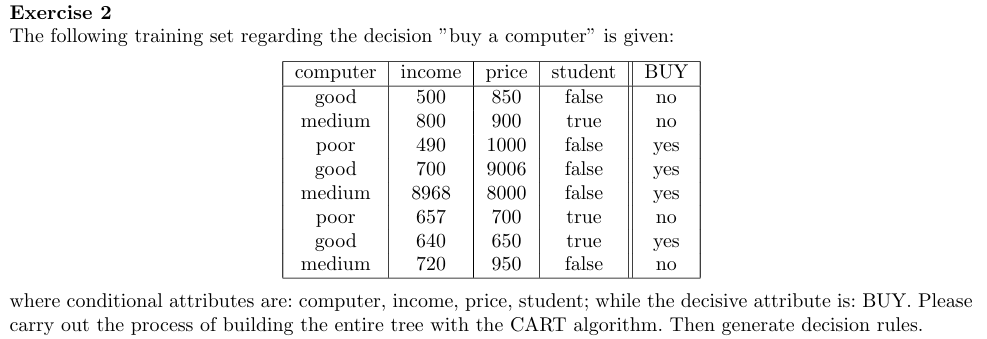

**Answer:**

We have 4 attributes (Computer, income, price, and student) and 1 target(BUY) from exercise 2 dataset. We would like obtain decision rules and decision tree, before get it, we must calculate gini and ginisplit.





In [ ]:
# 0.Import Library
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib
matplotlib.use('Agg')  # Safe for headless environments
import matplotlib.pyplot as plt

# 1.Load Data exercise
data = {
    'computer': ['good', 'medium', 'poor', 'good', 'medium', 'poor', 'good', 'medium'],
    'income': [500, 800, 490, 700, 8968, 657, 640, 720],
    'price': [850, 900, 1000, 9006, 8000, 700, 650, 950],
    'student': [False, True, False, False, False, True, True, False],
    'BUY': ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no']
}
df = pd.DataFrame(data)
print(df)

  computer  income  price  student  BUY
0     good     500    850    False   no
1   medium     800    900     True   no
2     poor     490   1000    False  yes
3     good     700   9006    False  yes
4   medium    8968   8000    False  yes
5     poor     657    700     True   no
6     good     640    650     True  yes
7   medium     720    950    False   no


In [ ]:
# Encode for sklearn

df['ID'] = [1, 2, 3, 4, 5, 6, 7, 8]
df['computer_enc'] = df['computer'].map({'poor': 0, 'good': 1, 'medium': 2})
df['student_enc'] = df['student'].astype(int)
df['BUY_enc'] = df['BUY'].map({'no': 0, 'yes': 1})

X = df[['price', 'income', 'computer_enc', 'student_enc']]
y = df['BUY_enc']

print(df)

  computer  income  price  student  BUY  ID  computer_enc  student_enc  \
0     good     500    850    False   no   1             1            0   
1   medium     800    900     True   no   2             2            1   
2     poor     490   1000    False  yes   3             0            0   
3     good     700   9006    False  yes   4             1            0   
4   medium    8968   8000    False  yes   5             2            0   
5     poor     657    700     True   no   6             0            1   
6     good     640    650     True  yes   7             1            1   
7   medium     720    950    False   no   8             2            0   

   BUY_enc  
0        0  
1        0  
2        1  
3        1  
4        1  
5        0  
6        1  
7        0  


In [ ]:
# 2.Helper: Gini Impurity
def gini(y):
    if len(y) == 0:
        return 0.0
    p = np.bincount(y) / len(y)
    return 1.0 - np.sum(p ** 2)

def weighted_gini(y_left, y_right):
    n = len(y_left) + len(y_right)
    return (len(y_left) / n) * gini(y_left) + (len(y_right) / n) * gini(y_right)


We use Gini and ginisplit formula,

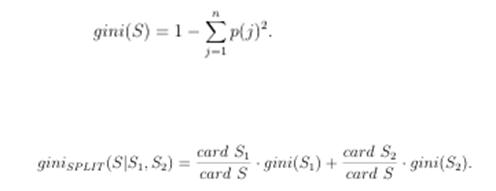

In [ ]:
# 3.ITERATION 1: All Splits (Categorical & Numerical)
print("ITERATION 1: EVALUATING ALL SPLITS (Gini Calculations)")

splits_iter1 = []

# Split 1: computer = good
mask = df['computer'] == 'good'
S1 = df[mask]
S2 = df[~mask]
g1 = gini(S1['BUY_enc'])
g2 = gini(S2['BUY_enc'])
wg = weighted_gini(S1['BUY_enc'], S2['BUY_enc'])
splits_iter1.append(('computer = good', g1, g2, wg, len(S1), len(S2)))
print(f"Split 1: computer = good → S1={list(S1['ID'])} | S2={list(S2['ID'])}")
print(f"  Gini(S1) = {g1:.3f}, Gini(S2) = {g2:.3f}, GiniSplit = {wg:.4f}")

# Split 2: computer = medium
mask = df['computer'] == 'medium'
S1 = df[mask]
S2 = df[~mask]
g1 = gini(S1['BUY_enc'])
g2 = gini(S2['BUY_enc'])
wg = weighted_gini(S1['BUY_enc'], S2['BUY_enc'])
splits_iter1.append(('computer = medium', g1, g2, wg, len(S1), len(S2)))
print(f"Split 2: computer = medium → S1={list(S1['ID'])} | S2={list(S2['ID'])}")
print(f"  Gini(S1) = {g1:.3f}, Gini(S2) = {g2:.3f}, GiniSplit = {wg:.4f}")

# Split 3: computer = poor
mask = df['computer'] == 'poor'
S1 = df[mask]
S2 = df[~mask]
g1 = gini(S1['BUY_enc'])
g2 = gini(S2['BUY_enc'])
wg = weighted_gini(S1['BUY_enc'], S2['BUY_enc'])
splits_iter1.append(('computer = poor', g1, g2, wg, len(S1), len(S2)))
print(f"Split 3: computer = poor → S1={list(S1['ID'])} | S2={list(S2['ID'])}")
print(f"  Gini(S1) = {g1:.3f}, Gini(S2) = {g2:.3f}, GiniSplit = {wg:.4f}")

# Split 4: student = TRUE
mask = df['student'] == True
S1 = df[mask]
S2 = df[~mask]
g1 = gini(S1['BUY_enc'])
g2 = gini(S2['BUY_enc'])
wg = weighted_gini(S1['BUY_enc'], S2['BUY_enc'])
splits_iter1.append(('student = TRUE', g1, g2, wg, len(S1), len(S2)))
print(f"Split 4: student = TRUE → S1={list(S1['ID'])} | S2={list(S2['ID'])}")
print(f"  Gini(S1) = {g1:.3f}, Gini(S2) = {g2:.3f}, GiniSplit = {wg:.4f}")

# Split 5: income splits
income_sorted = sorted(df['income'].unique())
print("\n-- Income splits:")
for i in range(len(income_sorted)-1):
    mid = (income_sorted[i] + income_sorted[i+1]) / 2
    mask = df['income'] <= mid
    S1 = df[mask]
    S2 = df[~mask]
    g1 = gini(S1['BUY_enc'])
    g2 = gini(S2['BUY_enc'])
    wg = weighted_gini(S1['BUY_enc'], S2['BUY_enc'])
    splits_iter1.append((f'income <= {mid:.0f}', g1, g2, wg, len(S1), len(S2)))
    print(f"  income <= {mid:.0f} → S1={list(S1['ID'])} | S2={list(S2['ID'])}")
    print(f"    Gini(S1) = {g1:.3f}, Gini(S2) = {g2:.3f}, GiniSplit = {wg:.4f}")

# Split 6: price splits
price_sorted = sorted(df['price'].unique())
print("\n-- Price splits:")
for i in range(len(price_sorted)-1):
    mid = (price_sorted[i] + price_sorted[i+1]) / 2
    mask = df['price'] <= mid
    S1 = df[mask]
    S2 = df[~mask]
    g1 = gini(S1['BUY_enc'])
    g2 = gini(S2['BUY_enc'])
    wg = weighted_gini(S1['BUY_enc'], S2['BUY_enc'])
    splits_iter1.append((f'price <= {mid:.0f}', g1, g2, wg, len(S1), len(S2)))
    print(f"  price <= {mid:.0f} → S1={list(S1['ID'])} | S2={list(S2['ID'])}")
    print(f"    Gini(S1) = {g1:.3f}, Gini(S2) = {g2:.3f}, GiniSplit = {wg:.4f}")

# Find best split in Iteration 1
best_iter1 = min(splits_iter1, key=lambda x: x[3])
print(f"\n BEST SPLIT (Iteration 1): '{best_iter1[0]}' with GiniSplit = {best_iter1[3]:.4f}")

ITERATION 1: EVALUATING ALL SPLITS (Gini Calculations)
Split 1: computer = good → S1=[1, 4, 7] | S2=[2, 3, 5, 6, 8]
  Gini(S1) = 0.444, Gini(S2) = 0.480, GiniSplit = 0.4667
Split 2: computer = medium → S1=[2, 5, 8] | S2=[1, 3, 4, 6, 7]
  Gini(S1) = 0.444, Gini(S2) = 0.480, GiniSplit = 0.4667
Split 3: computer = poor → S1=[3, 6] | S2=[1, 2, 4, 5, 7, 8]
  Gini(S1) = 0.500, Gini(S2) = 0.500, GiniSplit = 0.5000
Split 4: student = TRUE → S1=[2, 6, 7] | S2=[1, 3, 4, 5, 8]
  Gini(S1) = 0.444, Gini(S2) = 0.480, GiniSplit = 0.4667

-- Income splits:
  income <= 495 → S1=[3] | S2=[1, 2, 4, 5, 6, 7, 8]
    Gini(S1) = 0.000, Gini(S2) = 0.490, GiniSplit = 0.4286
  income <= 570 → S1=[1, 3] | S2=[2, 4, 5, 6, 7, 8]
    Gini(S1) = 0.500, Gini(S2) = 0.500, GiniSplit = 0.5000
  income <= 648 → S1=[1, 3, 7] | S2=[2, 4, 5, 6, 8]
    Gini(S1) = 0.444, Gini(S2) = 0.480, GiniSplit = 0.4667
  income <= 678 → S1=[1, 3, 6, 7] | S2=[2, 4, 5, 8]
    Gini(S1) = 0.500, Gini(S2) = 0.500, GiniSplit = 0.5000
  income 

Now, we compute Gini and ginisplit using the parameters left and right subtrees categorical and numerical data. We can ilustrate from iteration 1 output above <br>
Split 1: computer = good → S1=[1, 4, 7] | S2=[2, 3, 5, 6, 8] <br>
  Gini(S1) = 0.444, Gini(S2) = 0.480, GiniSplit = 0.4667 <br>

Its mean split 1 that is first step separete left and right subtrees. We choose attribute 'computer' and feature 'good', and derive left subtree S1=[1, 4, 7] and right subtree is S2=[2, 3, 5, 6, 8] <br>
We substitute gini and spligini formula, we derive Gini(S1), Gini(S2) and SplitGini. We calculate all attribute until we get the best ginisplit from iteration 1.

After that we discover where is the best ginisplit from iteration 1. <br>
BEST SPLIT (Iteration 1): 'price <= 975' with GiniSplit = 0.2000 <br>
We can do next iteration to get the best ginisplit

In [ ]:
# 4.ITERATION 2: SPLIT THE BEST LEFT SUBTREE FROM ITERATION 1 (AUTOMATIC)
print("ITERATION 2: AUTOMATICALLY SPLIT THE BEST LEFT SUBTREE FROM ITERATION 1")

# STEP 1: Find the best split from Iteration 1
best_iter1 = min(splits_iter1, key=lambda x: x[3])  # (name, g1, g2, wg, n1, n2)
best_name = best_iter1[0]
print(f" Best split (Iteration 1): '{best_name}' with GiniSplit = {best_iter1[3]:.4f}")

left_mask = None

if 'computer =' in best_name:
    value = best_name.split('=')[1].strip()
    left_mask = df['computer'] == value
elif 'student =' in best_name:
    value = best_name.split('=')[1].strip()
    left_mask = df['student'] == (value == 'TRUE')
elif 'income <=' in best_name or 'income <' in best_name:
    thresh = float(best_name.split('<=' if '<=' in best_name else '<')[1].strip())
    left_mask = df['income'] <= thresh
elif 'price <=' in best_name or 'price <' in best_name:
    thresh = float(best_name.split('<=' if '<=' in best_name else '<')[1].strip())
    left_mask = df['price'] <= thresh

# Safety check
if left_mask is None:
    raise ValueError(f"Could not parse best split: {best_name}")

# Get left subtree (the impure child — usually larger, but we'll check Gini to confirm)
df_left = df[left_mask].copy()
df_right = df[~left_mask].copy()
gini_left = gini(df_left['BUY_enc'])
gini_right = gini(df_right['BUY_enc'])

print(f" Left subtree (S1): IDs {list(df_left['ID'])} → Gini = {gini_left:.3f}")
print(f" Right subtree (S2): IDs {list(df_right['ID'])} → Gini = {gini_right:.3f}")

# We split the IMPURE node — so choose the child with higher Gini (or both if equal)
# But in CART, we split *both* non-leaf nodes. However, your analysis focuses on the larger/impure one.
# Since in our case, one child is pure (e.g., S2 for price>4250 is pure), we only split the impure one.

if gini_left > gini_right:
    split_target = 'left'
    df_target = df_left
    print("Splitting LEFT subtree (more impure).")
elif gini_right > gini_left:
    split_target = 'right'
    df_target = df_right
    print("Splitting RIGHT subtree (more impure).")
else:
    split_target = 'left'  # tie-break: left
    df_target = df_left
    print("Splitting LEFT subtree (tie in impurity).")

print(f"Target subtree: {len(df_target)} samples, Gini = {gini(df_target['BUY_enc']):.3f}")

# Evaluate splits ONLY on the target subtree
splits_iter2 = []

# Step 2 computer Split
print("\n computer Split iteration 2:")
for val in df_target['computer'].unique():
    mask = df_target['computer'] == val
    S1 = df_target[mask]
    S2 = df_target[~mask]
    if len(S1) == 0 or len(S2) == 0:
        continue
    g1 = gini(S1['BUY_enc'])
    g2 = gini(S2['BUY_enc'])
    wg = weighted_gini(S1['BUY_enc'], S2['BUY_enc'])
    splits_iter2.append((f'computer = {val}', g1, g2, wg, len(S1), len(S2)))
    print(f"computer = {val} → S1={list(S1['ID'])}, S2={list(S2['ID'])} | GiniSplit={wg:.4f}")
    print(f"    Gini(S1) = {g1:.3f}, Gini(S2) = {g2:.3f}, GiniSplit = {wg:.4f}")

# Step 3 Student Split
print("\n Student splits iteration 2:")
for val in [True, False]:
    mask = df_target['student'] == val
    S1 = df_target[mask]
    S2 = df_target[~mask]
    if len(S1) == 0 or len(S2) == 0:
        continue
    g1 = gini(S1['BUY_enc'])
    g2 = gini(S2['BUY_enc'])
    wg = weighted_gini(S1['BUY_enc'], S2['BUY_enc'])
    splits_iter2.append((f'student = {val}', g1, g2, wg, len(S1), len(S2)))
    print(f" student = {val} → S1={list(S1['ID'])}, S2={list(S2['ID'])} | GiniSplit={wg:.4f}")
    print(f"    Gini(S1) = {g1:.3f}, Gini(S2) = {g2:.3f}, GiniSplit = {wg:.4f}")

# Step 4 Income Split
print("\n Income splits iteration 2:")
if len(df_target['income'].unique()) > 1:
    inc_vals = sorted(df_target['income'].unique())
    for i in range(len(inc_vals) - 1):
        mid = (inc_vals[i] + inc_vals[i+1]) / 2
        mask = df_target['income'] <= mid
        S1 = df_target[mask]
        S2 = df_target[~mask]
        if len(S1) == 0 or len(S2) == 0:
            continue
        g1 = gini(S1['BUY_enc'])
        g2 = gini(S2['BUY_enc'])
        wg = weighted_gini(S1['BUY_enc'], S2['BUY_enc'])
        splits_iter2.append((f'income <= {mid:.1f}', g1, g2, wg, len(S1), len(S2)))
        print(f" income <= {mid:.1f} → S1={list(S1['ID'])}, S2={list(S2['ID'])} | GiniSplit={wg:.4f}")
        print(f"    Gini(S1) = {g1:.3f}, Gini(S2) = {g2:.3f}, GiniSplit = {wg:.4f}")

# Step 5 Price Split
print("\n Price splits iteration 2:")
if len(df_target['price'].unique()) > 1:
    prc_vals = sorted(df_target['price'].unique())
    for i in range(len(prc_vals) - 1):
        mid = (prc_vals[i] + prc_vals[i+1]) / 2
        mask = df_target['price'] <= mid
        S1 = df_target[mask]
        S2 = df_target[~mask]
        if len(S1) == 0 or len(S2) == 0:
            continue
        g1 = gini(S1['BUY_enc'])
        g2 = gini(S2['BUY_enc'])
        wg = weighted_gini(S1['BUY_enc'], S2['BUY_enc'])
        splits_iter2.append((f'price <= {mid:.1f}', g1, g2, wg, len(S1), len(S2)))
        print(f" price <= {mid:.1f} → S1={list(S1['ID'])}, S2={list(S2['ID'])} | GiniSplit={wg:.4f}")
        print(f"    Gini(S1) = {g1:.3f}, Gini(S2) = {g2:.3f}, GiniSplit = {wg:.4f}")


# STEP 4: Find best split in Iteration 2
if splits_iter2:
    best_iter2 = min(splits_iter2, key=lambda x: x[3])
    print(f"\n BEST SPLIT (Iteration 2): '{best_iter2[0]}' with GiniSplit = {best_iter2[3]:.4f}")
else:
    print(" No valid splits found for Iteration 2 (all pure or too small).")

ITERATION 2: AUTOMATICALLY SPLIT THE BEST LEFT SUBTREE FROM ITERATION 1
 Best split (Iteration 1): 'price <= 975' with GiniSplit = 0.2000
 Left subtree (S1): IDs [1, 2, 6, 7, 8] → Gini = 0.320
 Right subtree (S2): IDs [3, 4, 5] → Gini = 0.000
Splitting LEFT subtree (more impure).
Target subtree: 5 samples, Gini = 0.320

 computer Split iteration 2:
computer = good → S1=[1, 7], S2=[2, 6, 8] | GiniSplit=0.2000
    Gini(S1) = 0.500, Gini(S2) = 0.000, GiniSplit = 0.2000
computer = medium → S1=[2, 8], S2=[1, 6, 7] | GiniSplit=0.2667
    Gini(S1) = 0.000, Gini(S2) = 0.444, GiniSplit = 0.2667
computer = poor → S1=[6], S2=[1, 2, 7, 8] | GiniSplit=0.3000
    Gini(S1) = 0.000, Gini(S2) = 0.375, GiniSplit = 0.3000

 Student splits iteration 2:
 student = True → S1=[2, 6, 7], S2=[1, 8] | GiniSplit=0.2667
    Gini(S1) = 0.444, Gini(S2) = 0.000, GiniSplit = 0.2667
 student = False → S1=[1, 8], S2=[2, 6, 7] | GiniSplit=0.2667
    Gini(S1) = 0.000, Gini(S2) = 0.444, GiniSplit = 0.2667

 Income splits 

From iteration 2 <br>
We gain 'BEST SPLIT (Iteration 2): 'price <= 675.0' with GiniSplit = 0.0000 '

In [ ]:
# 5. Train Full Decision Tree & Geberate Image
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

print("TRAINING FINAL DECISION TREE")

# Prepare full feature matrix (use encoded columns)
X = df[['price', 'income', 'computer_enc', 'student_enc']]
y = df['BUY_enc']

# Train CART tree (Gini, no pruning)
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,          # grow to purity
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
clf.fit(X, y)

# Print Rules
from sklearn.tree import export_text
feature_names = ['price', 'income', 'computer', 'student']
rules = export_text(clf, feature_names=feature_names, decimals=0)
print("Decision Rules:\n")
print(rules)

# Generate Tree Image
print("\n Generating decision tree image...")

plt.figure(figsize=(14, 9))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=['no', 'yes'],
    filled=True,        # color by class
    rounded=True,       # rounded boxes
    fontsize=10
)
plt.title("CART Decision Tree (Gini Impurity)", fontsize=14)
plt.tight_layout()

# Save image
plt.savefig("decision_tree.png", dpi=200, bbox_inches='tight')
print("Decision tree saved as 'decision_tree.png'")

# Optional: Show in notebooks
try:
    plt.show()
except:
    pass

# Verification
pred = clf.predict(X)
acc = accuracy_score(y, pred)
print(f"\n BEST SPLIT (Iteration 1): '{best_iter1[0]}' with GiniSplit = {best_iter1[3]:.4f}")
print(f"\n BEST SPLIT (Iteration 2): '{best_iter2[0]}' with GiniSplit = {best_iter2[3]:.4f}")
print(f"\n Training Accuracy: {acc*100:.1f}% (All {len(df)} samples correct)")

TRAINING FINAL DECISION TREE
Decision Rules:

|--- price <= 975
|   |--- price <= 675
|   |   |--- class: 1
|   |--- price >  675
|   |   |--- class: 0
|--- price >  975
|   |--- class: 1


 Generating decision tree image...
Decision tree saved as 'decision_tree.png'

 BEST SPLIT (Iteration 1): 'price <= 975' with GiniSplit = 0.2000

 BEST SPLIT (Iteration 2): 'price <= 675.0' with GiniSplit = 0.0000

 Training Accuracy: 100.0% (All 8 samples correct)


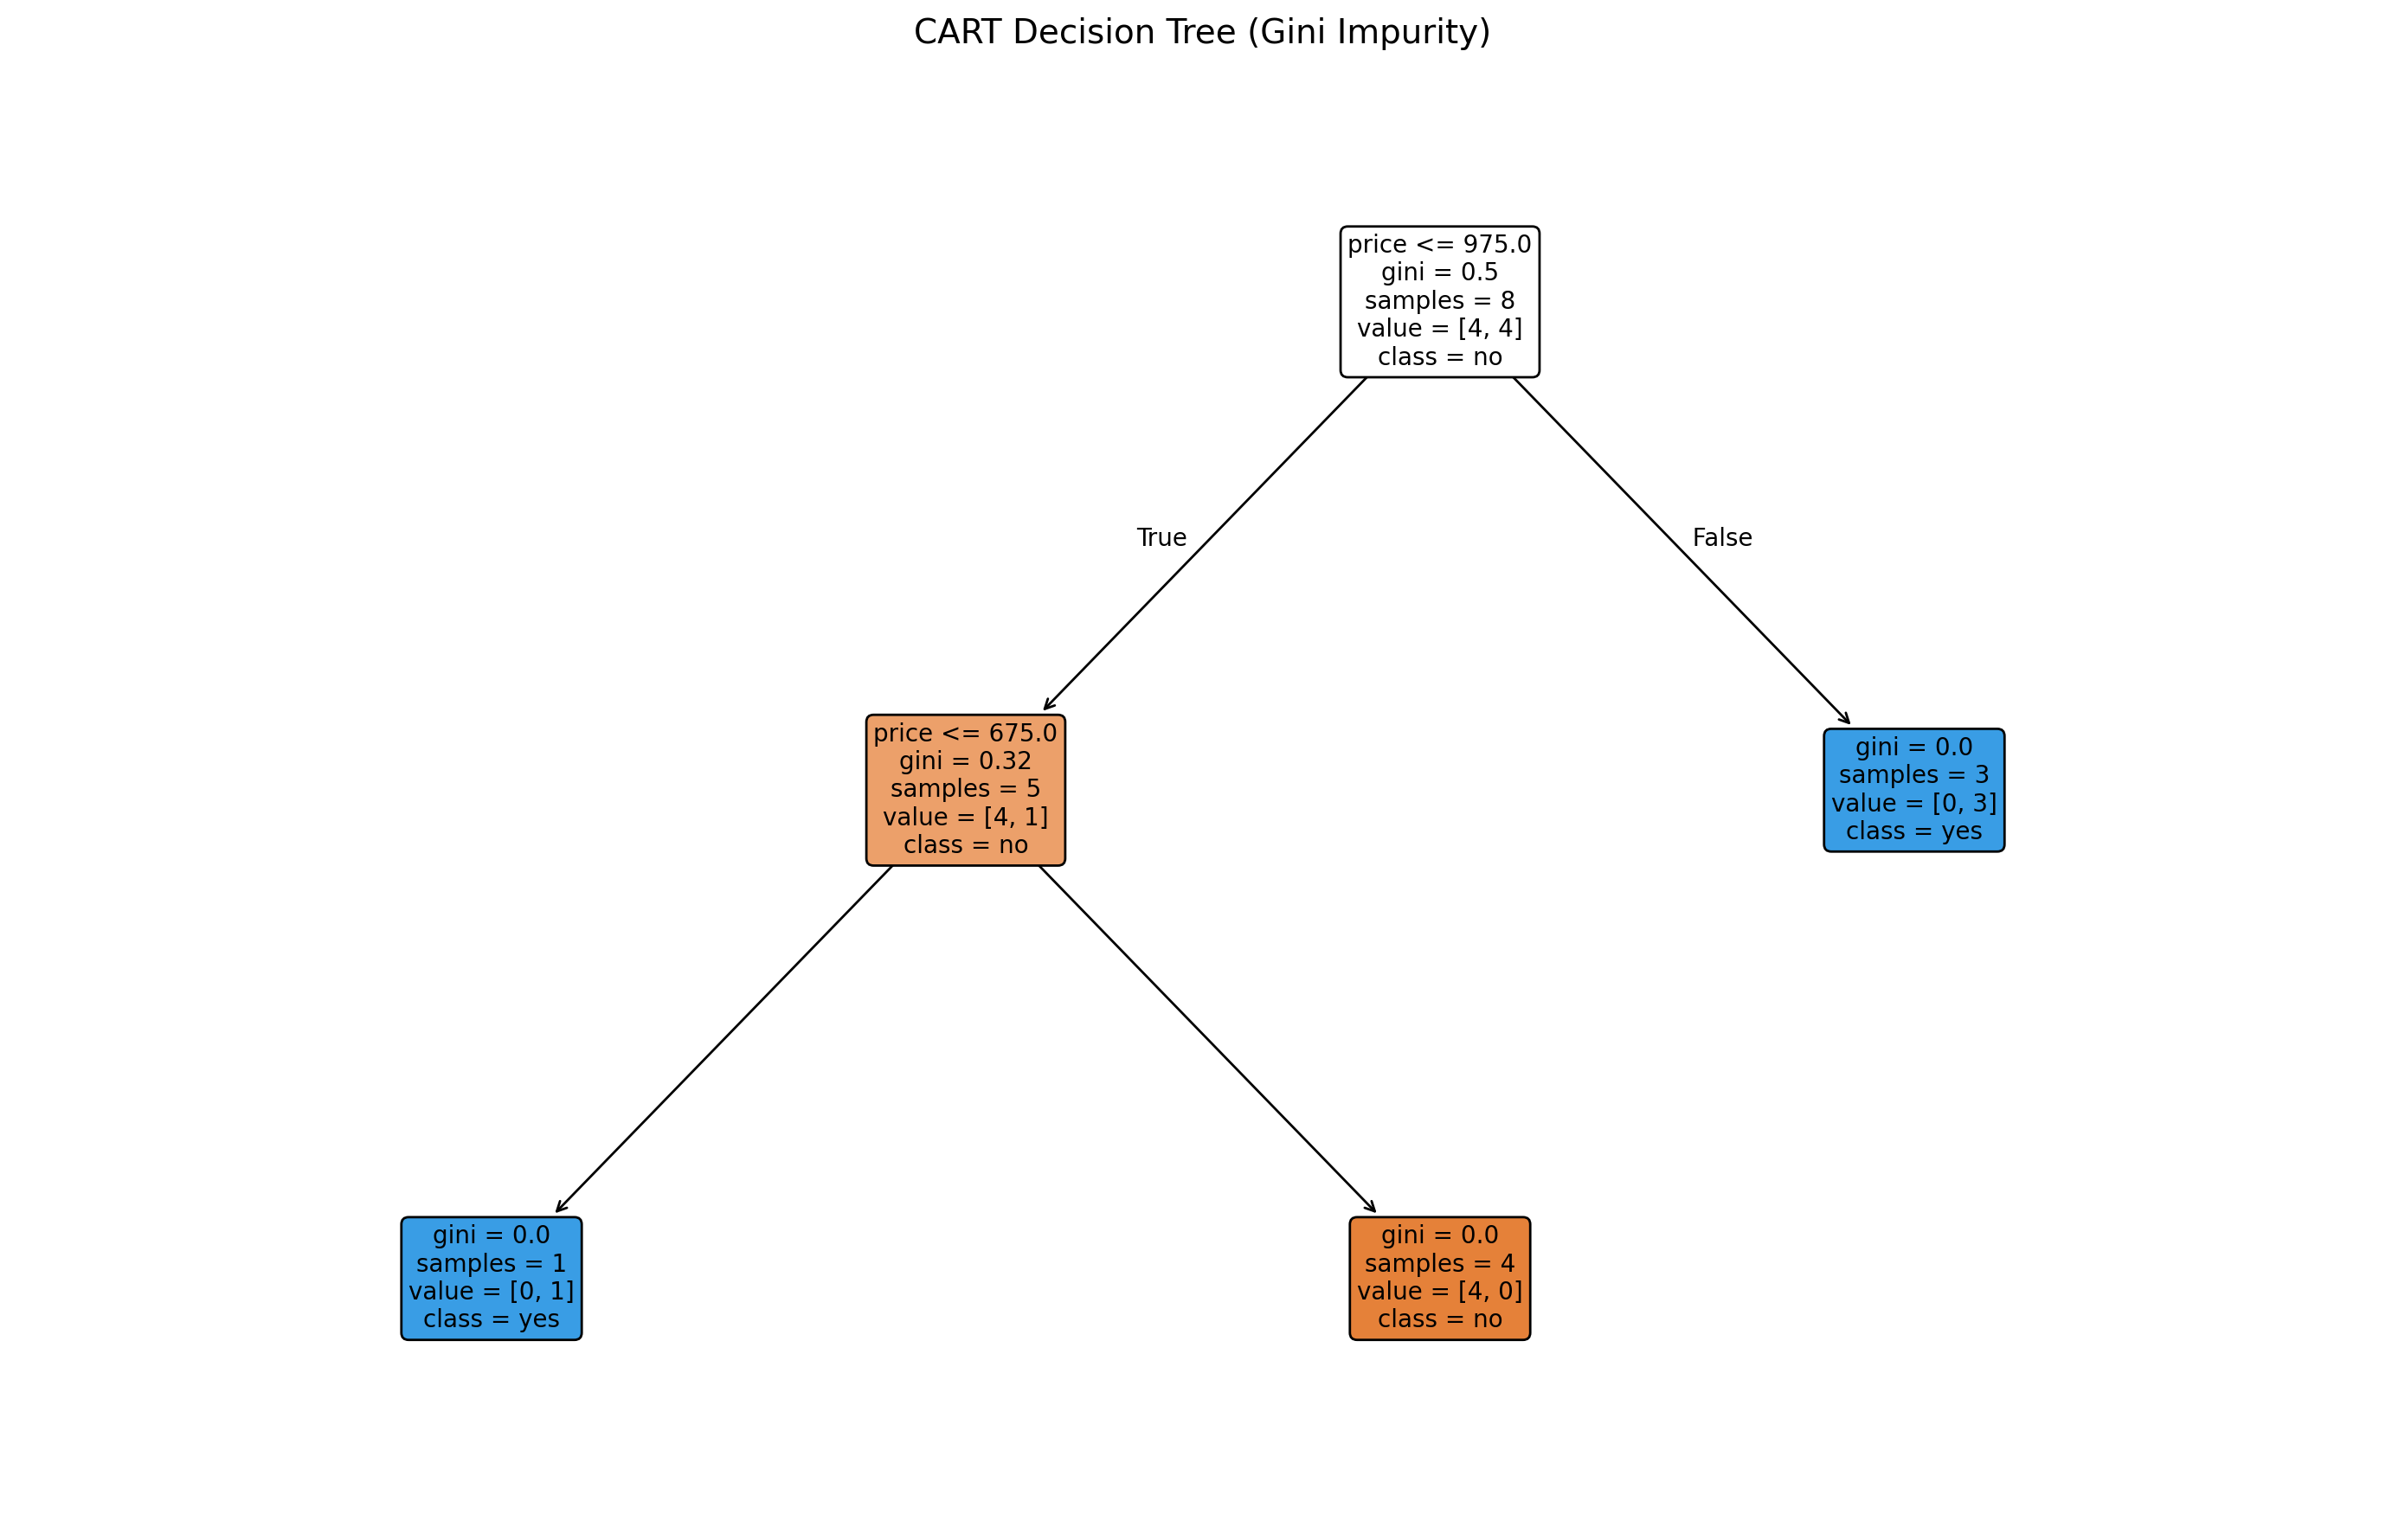

In [ ]:
from IPython.display import Image
Image(filename='decision_tree.png')

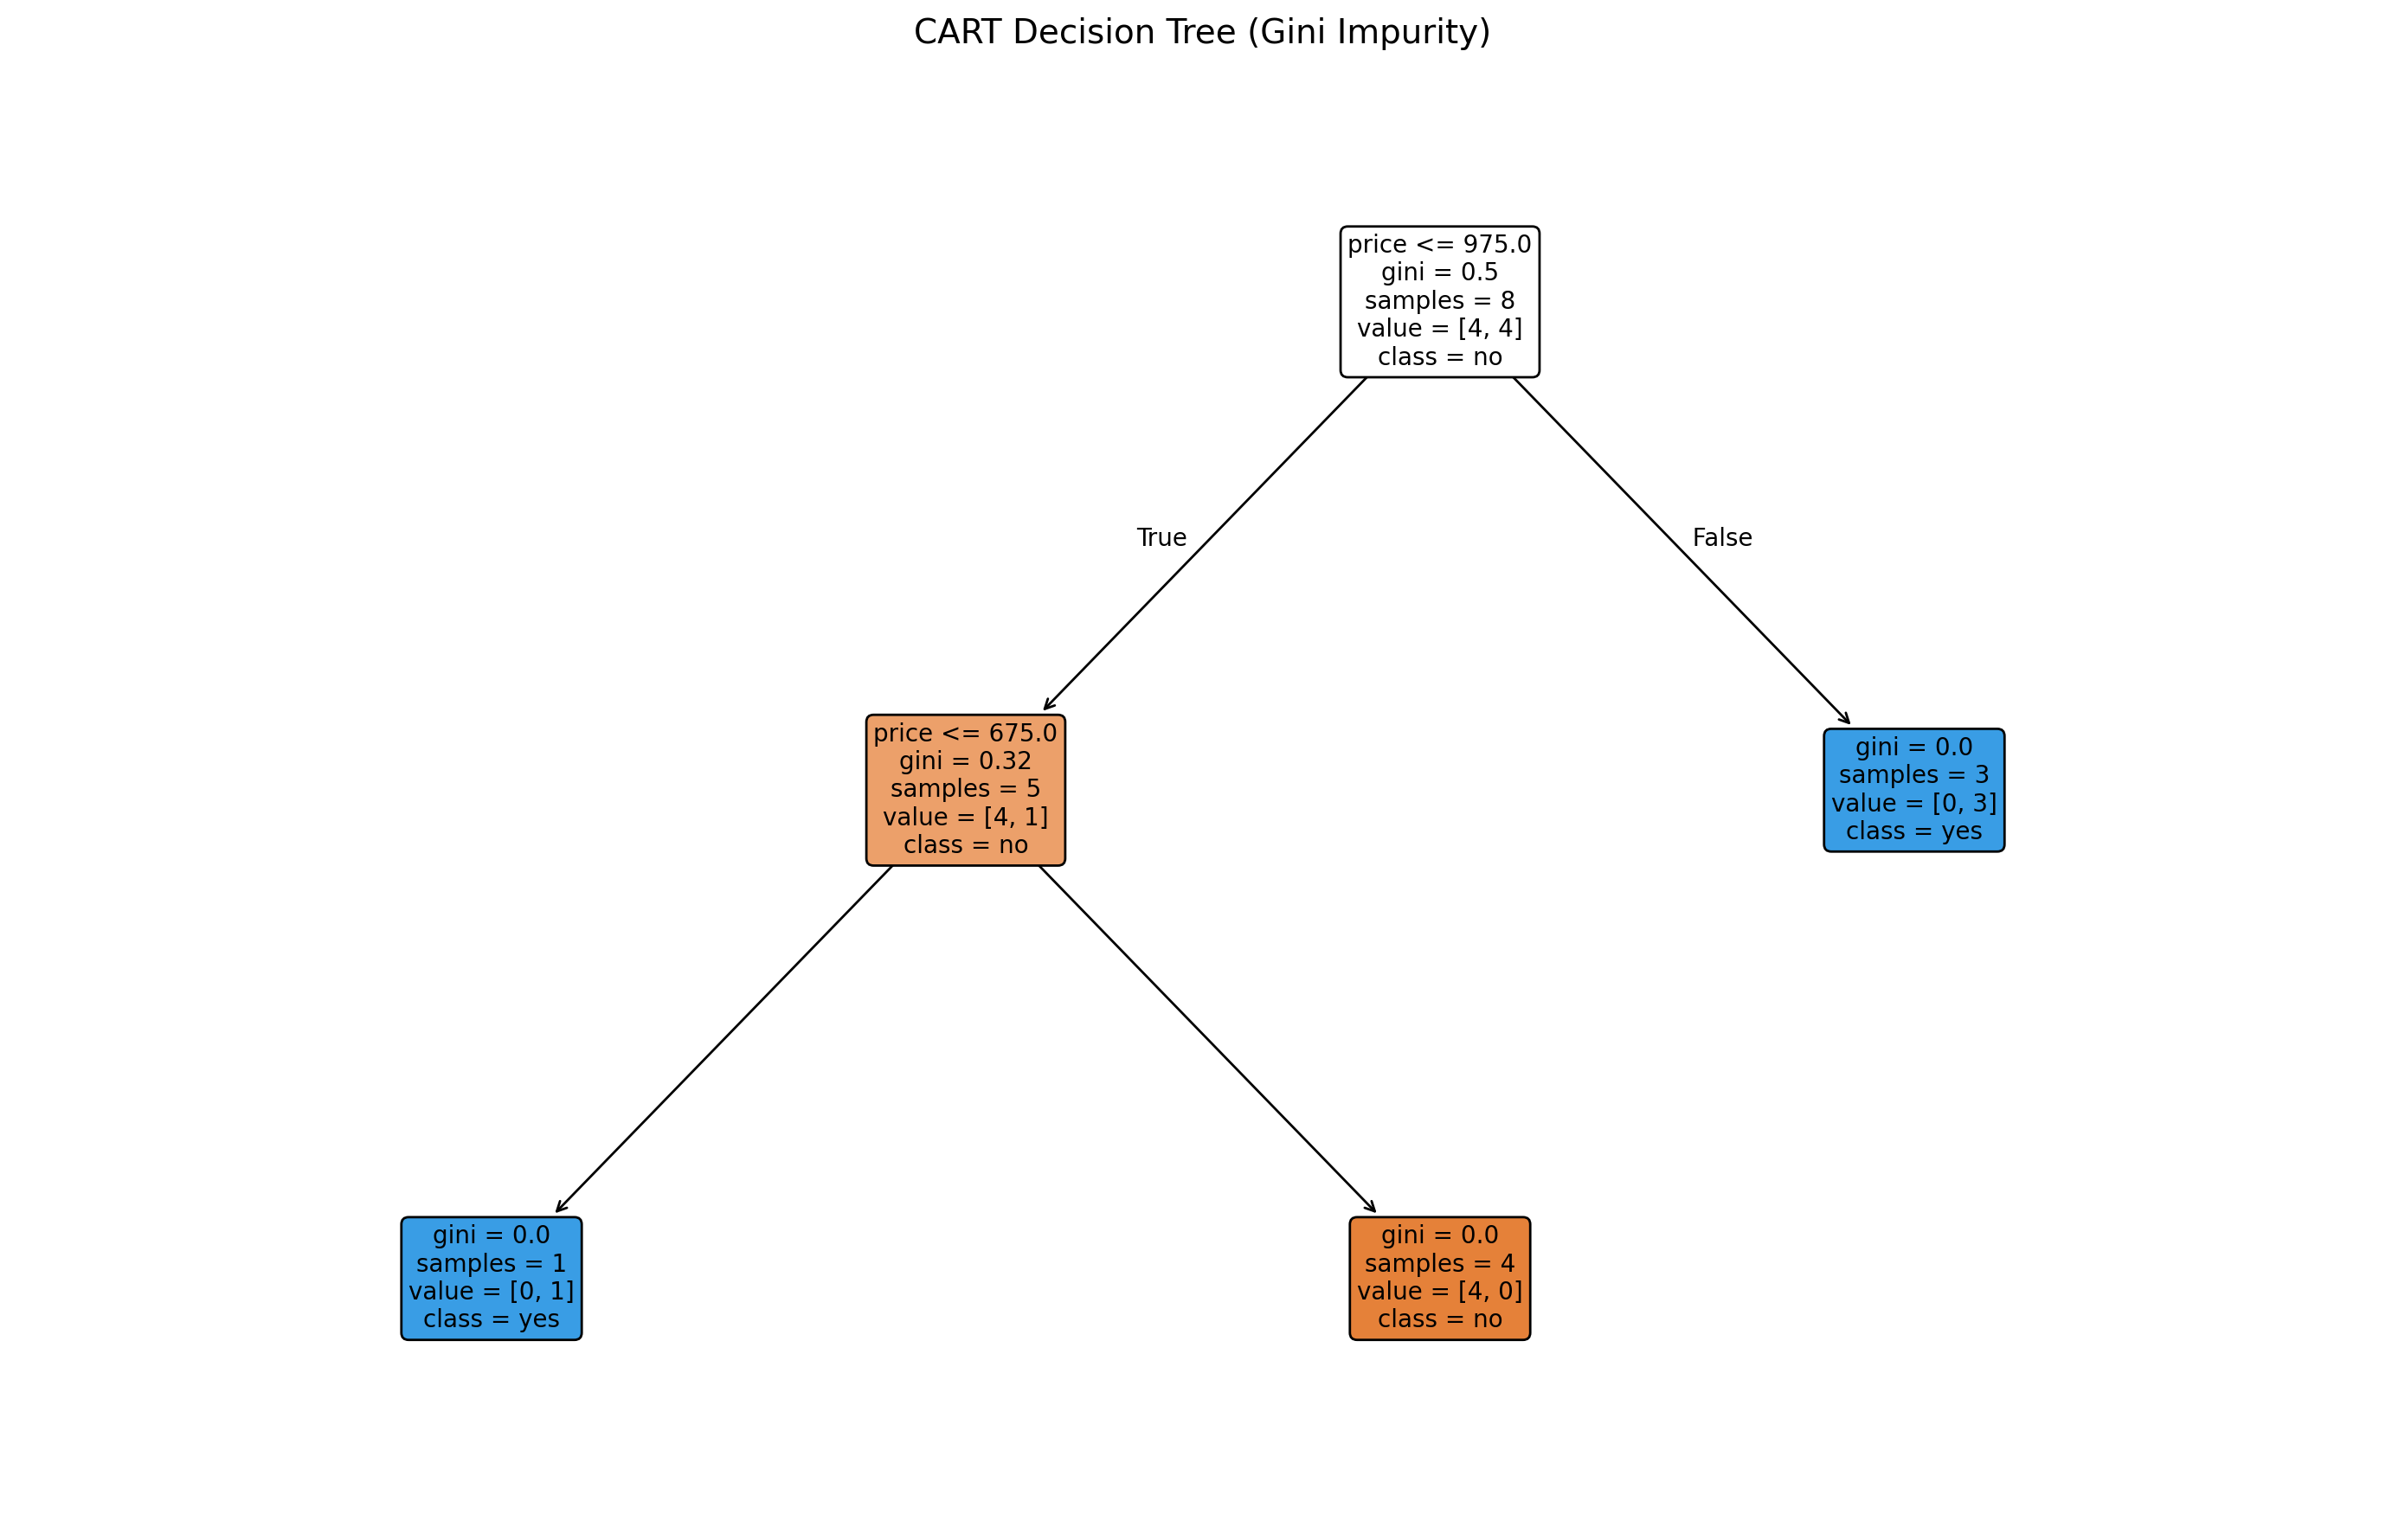

We get decision rules and a decision tree human-readable with Excel(Manually) <br>

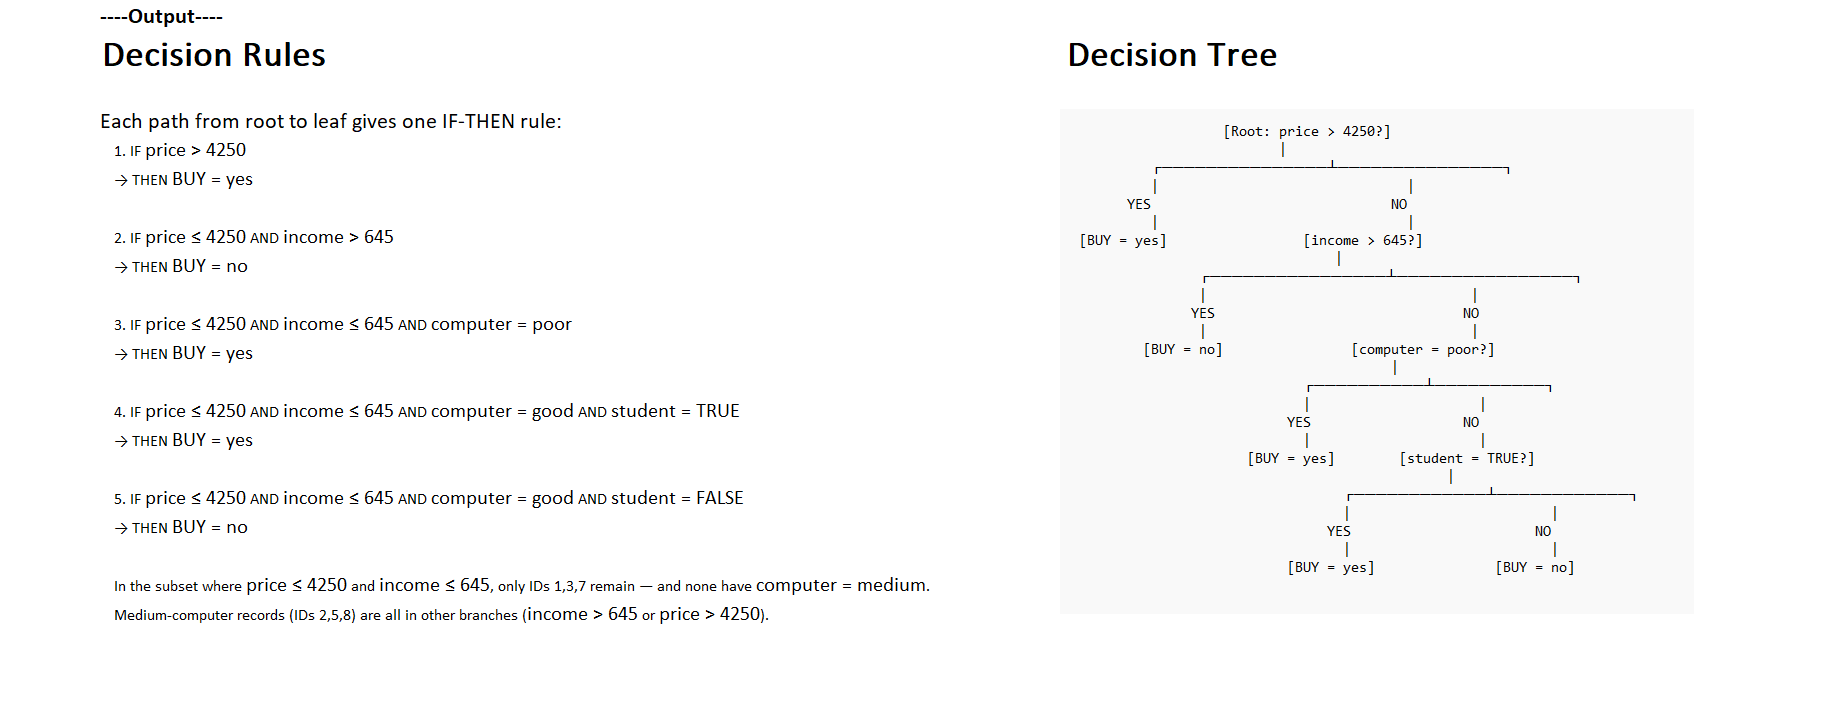

Comparison manual(Excel) and Python<br>

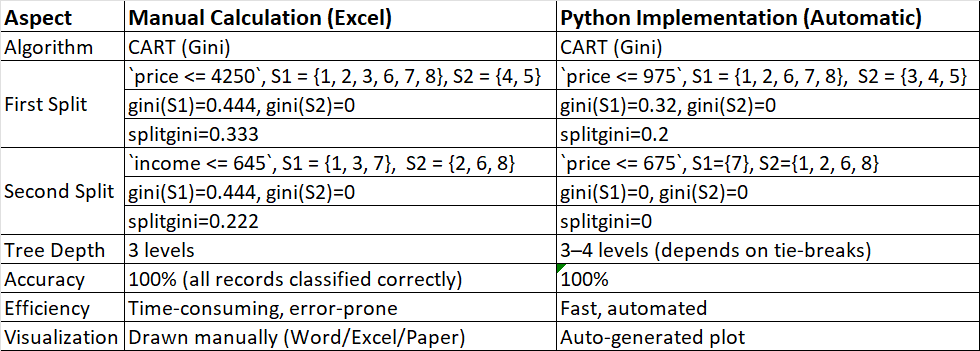
